# Homework 05
L. N. Jakubczyk

DATA 71200, Spring 2026

# Logistic Regression Models: Stroke Prediction Dataset

For this homework I'm fitting three logistic regression models to predict the probability of stroke from a cross-sectional clinical dataset of 5,110 patients. The outcome is binary (stroke or no stroke), so logistic regression is the right tool: it models the log-odds of the event as a linear combination of predictors and keeps predicted probabilities between 0 and 1. I exponentiate the coefficients to read them as odds ratios, which have a direct clinical interpretation: an OR of 2.0 on a predictor means patients with that condition have twice the odds of stroke relative to the reference group.

I build the models in a hierarchical sequence, adding predictors in blocks, to see how much each block improves fit over the last. Model 1 is a demographic baseline with age and sex. Model 2 adds the two medical-history risk factors, hypertension and prior heart disease. Model 3 adds the clinical and lifestyle variables: average glucose level, BMI, and smoking status. I compare fit across models using McFadden's pseudo R^2, Nagelkerke's pseudo R^2, AIC, and a chi-square likelihood ratio test between each pair of nested models.

## How to run this notebook

Open in Jupyter Notebook and run all cells. Dependencies are installed automatically by the first cell.

Model claude-sonnet-4-6 used for boilerplate setup only; analysis and interpretation are my own.

## 1. Setup and Data Loading

Installing libraries, loading the CSV, and cleaning the data. There are 201 rows where BMI is recorded as 'N/A'; I pass na_values=['N/A'] to read_csv so those come in as actual NaN rather than a string, then drop those rows. I also drop one patient whose gender is 'Other' (N = 1) to keep binary sex coding clean. That leaves 4,908 complete cases. All three models run on the same sample so the fit statistics are directly comparable.

In [11]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "pandas", "numpy", "matplotlib", "seaborn",
                       "statsmodels", "scipy"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from IPython.display import display

# na_values=["N/A"] tells pandas to treat the literal string 'N/A' in the CSV
# as a missing value rather than a string; BMI has 201 such rows
df = pd.read_csv("05_healthcare-dataset-stroke-data 2.csv", na_values=["N/A"])

# one patient has gender='Other' (N=1); too small to dummy separately and
# would break the binary male/female coding, so drop it
df = df[df["gender"] != "Other"].copy()

# BMI is the only variable with missing data; dropping rather than imputing
# means all three models run on the exact same 4,908 rows, so pseudo R^2
# and AIC are directly comparable across models
df = df.dropna(subset=["bmi"]).reset_index(drop=True)

# create a binary sex dummy: male=1, female=0
df["male"] = (df["gender"] == "Male").astype(int)

# smoking has four categories; encode as three dummies so we can include
# it in a standard logistic formula; 'never smoked' is the reference group,
# meaning its effect is absorbed into the intercept
df["formerly_smoked"] = (df["smoking_status"] == "formerly smoked").astype(int)
df["smokes"]          = (df["smoking_status"] == "smokes").astype(int)
df["smoking_unknown"] = (df["smoking_status"] == "Unknown").astype(int)

print("Shape (complete cases):", df.shape)
print(f"Stroke cases: {df['stroke'].sum()} of {len(df)} ({df['stroke'].mean()*100:.2f}%)")
print()
# describe() is a quick sanity check that the ranges and means look reasonable
df.describe()

Shape (complete cases): (4908, 16)
Stroke cases: 209 of 4908 (4.26%)



,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,male,formerly_smoked,smokes,smoking_unknown
count,4908.000000,4908.000000,4908.000000,4908.000000,4908.000000,4908.00000,4908.000000,4908.000000,4908.000000,4908.000000,4908.000000
mean,37060.423594,42.868810,0.091891,0.049511,105.297402,28.89456,0.042584,0.409739,0.170334,0.150163,0.302160
std,20995.468407,22.556128,0.288901,0.216954,44.425550,7.85432,0.201937,0.491836,0.375964,0.357268,0.459241
min,77.000000,0.080000,0.000000,0.000000,55.120000,10.30000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18602.500000,25.000000,0.000000,0.000000,77.067500,23.50000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37580.500000,44.000000,0.000000,0.000000,91.680000,28.10000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55181.750000,60.000000,0.000000,0.000000,113.495000,33.10000,0.000000,1.000000,0.000000,0.000000,1.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.60000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Outcome Distribution and Sample Characteristics

Stroke is rare in this dataset, about 4 percent of patients. Before modeling I want to see how the key predictors differ between the two outcome groups, because any predictor with a large gap across groups will tend to show up in the models. The most striking split is on age: patients who experienced a stroke average about 68 years old, versus 42 for those who did not. Hypertension and heart disease also differ sharply across groups. Sex, BMI, and smoking show only modest raw differences.

Group means by stroke status:


,age,avg_glucose_level,bmi,hypertension,heart_disease,male
stroke,,,,,,
0,41.764,103.995,28.824,0.083,0.043,0.409
1,67.713,134.571,30.471,0.287,0.191,0.426



No-stroke N = 4699,  Stroke N = 209


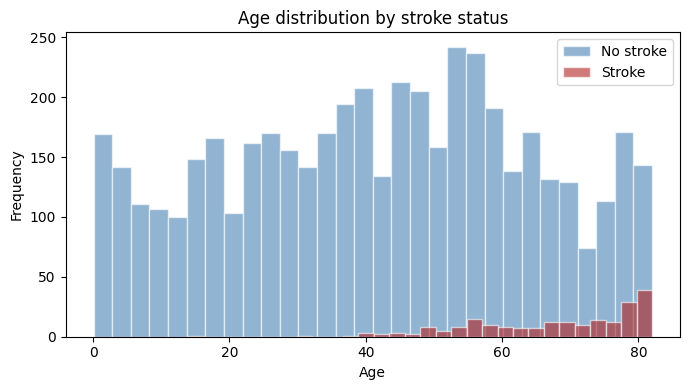

In [12]:
# group means give a quick read on which predictors separate the two groups;
# a large gap in means for a variable is a signal it will show up in the models
summary = df.groupby("stroke")[["age", "avg_glucose_level", "bmi",
                                 "hypertension", "heart_disease", "male"]].mean().round(3)
print("Group means by stroke status:")
display(summary)
print()
print(f"No-stroke N = {(df['stroke']==0).sum()},  Stroke N = {(df['stroke']==1).sum()}")

# overlay both groups on one histogram so the shift in age distribution is visible
# alpha=0.6 keeps both bars readable where they overlap
fig, ax = plt.subplots(figsize=(7, 4))
for s, label, color in [(0, "No stroke", "steelblue"), (1, "Stroke", "firebrick")]:
    ax.hist(df.loc[df["stroke"] == s, "age"], bins=30, alpha=0.6,
            label=label, color=color, edgecolor="white")
ax.set_xlabel("Age")
ax.set_ylabel("Frequency")
ax.set_title("Age distribution by stroke status")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Correlation Matrix

Pearson correlations among the numeric predictors and the outcome. Age has the strongest association with stroke (r ~ 0.25). Hypertension and heart disease follow at lower magnitudes. BMI and sex are near zero against the outcome. The matrix also shows modest collinearity between some predictors; age correlates with hypertension and with marital status, which is worth keeping in mind when reading the regression coefficients.

Pearson correlation matrix:


,age,hypertension,heart_disease,avg_glucose_level,bmi,male,stroke
age,1.000,0.274,0.257,0.236,0.333,-0.030,0.232
hypertension,0.274,1.000,0.116,0.181,0.168,0.022,0.143
heart_disease,0.257,0.116,1.000,0.155,0.041,0.083,0.138
avg_glucose_level,0.236,0.181,0.155,1.000,0.176,0.053,0.139
bmi,0.333,0.168,0.041,0.176,1.000,-0.026,0.042
male,-0.030,0.022,0.083,0.053,-0.026,1.000,0.007
stroke,0.232,0.143,0.138,0.139,0.042,0.007,1.000


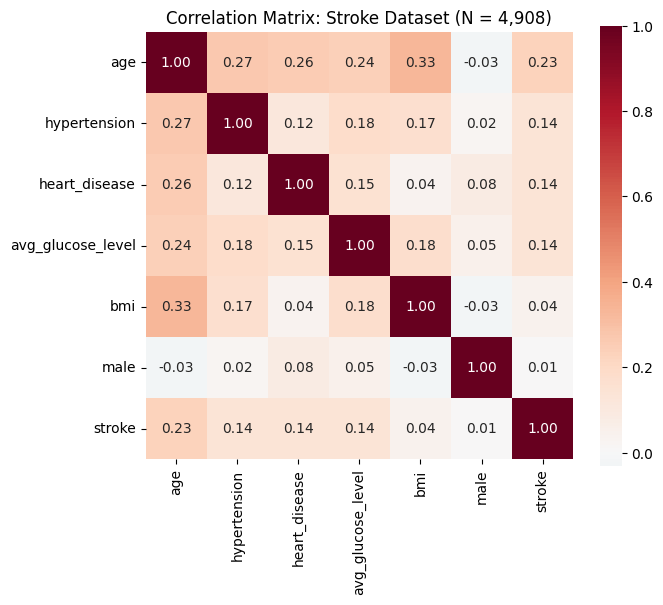

In [13]:
# restrict to the numeric predictors going into the models plus the outcome;
# work_type and Residence_type are categorical so they don't belong in a
# Pearson correlation matrix
corr_vars = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "male", "stroke"]
corr = df[corr_vars].corr()

print("Pearson correlation matrix:")
display(corr.round(3))

# center=0 anchors the colormap at zero so white cells = no correlation;
# RdBu_r makes positive correlations red and negative ones blue
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
plt.title("Correlation Matrix: Stroke Dataset (N = 4,908)")
plt.tight_layout()
plt.show()

## 4. Logistic Regression Models

All three models use statsmodels logit with a logistic link. Coefficients are on the log-odds scale; I exponentiate them to report odds ratios. I assess fit with two pseudo R^2 measures: McFadden's (1 minus the ratio of model log-likelihood to null log-likelihood) and Nagelkerke's (which rescales Cox-Snell R^2 to a maximum of 1 so it is more directly comparable to OLS R^2). AIC penalizes model complexity. I also run a chi-square likelihood ratio test between each pair of nested models to confirm the added block improves fit beyond chance.

I define helper functions once so I don't repeat them below.

In [14]:
def mcfadden_r2(res):
    # McFadden pseudo R^2: 1 - (log-likelihood of fitted model / log-likelihood of null model)
    # llnull is the intercept-only baseline; a value of 0 means no improvement over that
    return 1.0 - res.llf / res.llnull

def nagelkerke_r2(res):
    # Nagelkerke rescales Cox-Snell R^2 to its theoretical maximum so the result
    # spans [0, 1]; Cox-Snell alone can never reach 1.0 for a binary outcome
    n = res.nobs
    cox_snell = 1 - np.exp((2 / n) * (res.llnull - res.llf))
    cs_max    = 1 - np.exp(2 / n * res.llnull)
    return cox_snell / cs_max

def lr_test(res_small, res_large):
    # likelihood ratio chi-square test for two nested models:
    # LR = 2 * (LL_large - LL_small), df = difference in free parameters
    lr_stat = 2 * (res_large.llf - res_small.llf)
    df_diff = int(res_large.df_model - res_small.df_model)
    p_val   = stats.chi2.sf(lr_stat, df_diff)
    return lr_stat, df_diff, p_val

def fit_logit(formula):
    # disp=False suppresses the iteration log statsmodels prints during fitting
    return smf.logit(formula, data=df).fit(disp=False)

### Model 1: Demographic Baseline (Age and Sex)

Starting from the simplest possible demographic model. Age is continuous; sex is a binary dummy (male = 1, female = 0). This sets a baseline that the later models have to beat to justify their added complexity.

In [15]:
res1 = fit_logit("stroke ~ age + male")

print("Model 1: stroke ~ age + male")
# summary() shows coefficients on the log-odds scale, standard errors, z-scores, p-values
print(res1.summary())
print(f"\nMcFadden pseudo R^2:   {mcfadden_r2(res1):.4f}")
print(f"Nagelkerke pseudo R^2: {nagelkerke_r2(res1):.4f}")
print(f"AIC:                   {res1.aic:.2f}")
# exp() converts log-odds coefficients to odds ratios, which are easier to interpret
print("\nOdds ratios (exp of coefficients):")
print(np.exp(res1.params).round(4))

Model 1: stroke ~ age + male
                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 4908
Model:                          Logit   Df Residuals:                     4905
Method:                           MLE   Df Model:                            2
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.1857
Time:                        02:12:35   Log-Likelihood:                -703.64
converged:                       True   LL-Null:                       -864.15
Covariance Type:            nonrobust   LLR p-value:                 1.947e-70
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -7.4200      0.369    -20.093      0.000      -8.144      -6.696
age            0.0750      0.005     14.086      0.000       0.065       0.085
male           0.0970  

### Model 2: Add Medical History (Hypertension and Heart Disease)

Extending Model 1 by adding the two binary indicators for prior medical diagnoses. Both are already coded 0/1 in the dataset. This block tests whether known cardiovascular risk factors improve prediction beyond the demographic baseline.

In [16]:
# hypertension and heart_disease are already 0/1 in the dataset so no recoding needed;
# keeping age and male in the formula even though sex was not significant in Model 1
# preserves the hierarchical structure so pseudo R^2 gains are incremental
res2 = fit_logit("stroke ~ age + male + hypertension + heart_disease")

print("Model 2: stroke ~ age + male + hypertension + heart_disease")
print(res2.summary())
print(f"\nMcFadden pseudo R^2:   {mcfadden_r2(res2):.4f}")
print(f"Nagelkerke pseudo R^2: {nagelkerke_r2(res2):.4f}")
print(f"AIC:                   {res2.aic:.2f}")
print("\nOdds ratios (exp of coefficients):")
print(np.exp(res2.params).round(4))

Model 2: stroke ~ age + male + hypertension + heart_disease
                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 4908
Model:                          Logit   Df Residuals:                     4903
Method:                           MLE   Df Model:                            4
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.1965
Time:                        02:12:35   Log-Likelihood:                -694.31
converged:                       True   LL-Null:                       -864.15
Covariance Type:            nonrobust   LLR p-value:                 2.976e-72
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -7.2407      0.372    -19.448      0.000      -7.970      -6.511
age               0.0694      0.006     12.603      0.000     

### Model 3: Full Model (Add Glucose, BMI, and Smoking)

Adding the remaining clinical and lifestyle predictors. Average glucose level and BMI are continuous. Smoking status has four categories; I use three dummies (smokes, formerly_smoked, smoking_unknown) with 'never smoked' as the reference. Residence type and work type are excluded; their raw correlations with the outcome are near zero and they have no clear theoretical priority in a medical risk-factor model.

In [17]:
# split the formula string across two lines for readability; Python concatenates
# adjacent string literals so statsmodels sees one formula
res3 = fit_logit(
    "stroke ~ age + male + hypertension + heart_disease "
    "+ avg_glucose_level + bmi + smokes + formerly_smoked + smoking_unknown"
)

print("Model 3 (full model)")
print(res3.summary())
print(f"\nMcFadden pseudo R^2:   {mcfadden_r2(res3):.4f}")
print(f"Nagelkerke pseudo R^2: {nagelkerke_r2(res3):.4f}")
print(f"AIC:                   {res3.aic:.2f}")
# comparing these ORs to Model 2 shows how much the new block shifts each estimate
print("\nOdds ratios (exp of coefficients):")
print(np.exp(res3.params).round(4))

Model 3 (full model)
                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 4908
Model:                          Logit   Df Residuals:                     4898
Method:                           MLE   Df Model:                            9
Date:                Sun, 31 May 2026   Pseudo R-squ.:                  0.2077
Time:                        02:12:35   Log-Likelihood:                -684.69
converged:                       True   LL-Null:                       -864.15
Covariance Type:            nonrobust   LLR p-value:                 7.830e-72
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -7.8817      0.571    -13.799      0.000      -9.001      -6.762
age                   0.0690      0.006     11.808      0.000       0.058       0.081
mal

## 5. Model Comparison

Collecting McFadden and Nagelkerke pseudo R^2 and AIC across the three models, then running a chi-square likelihood ratio test between each pair of nested models. The LR test asks: does the improvement in log-likelihood from adding the new block exceed what we would expect by chance given the additional degrees of freedom? A significant chi-square says yes, the new block carries real information. Lower AIC and higher pseudo R^2 all agree: Model 3 fits best.

,Model,McFadden R^2,Nagelkerke R^2,AIC
0,Model 1: age + sex,0.1857,0.2133,1413.2702
1,Model 2: + hypertension + heart disease,0.1965,0.2253,1398.6267
2,Model 3: + glucose + BMI + smoking,0.2077,0.2376,1389.3815



Likelihood ratio tests (chi-square):
Model 1 vs Model 2: LR = 18.64, df = 2, p = 0.0001
Model 2 vs Model 3: LR = 19.25, df = 5, p = 0.0017


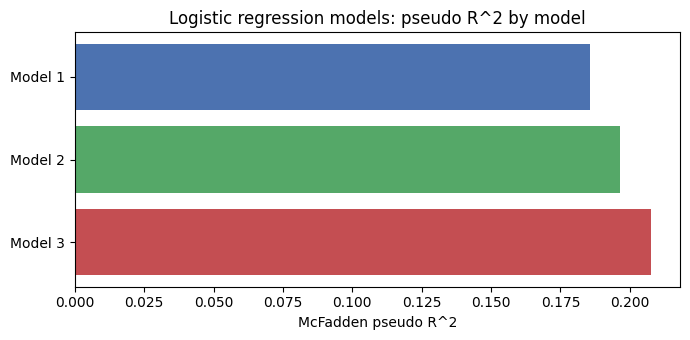

In [18]:
# each tuple is (label, McFadden R^2, Nagelkerke R^2, AIC)
rows = [
    ("Model 1: age + sex",
     mcfadden_r2(res1), nagelkerke_r2(res1), res1.aic),
    ("Model 2: + hypertension + heart disease",
     mcfadden_r2(res2), nagelkerke_r2(res2), res2.aic),
    ("Model 3: + glucose + BMI + smoking",
     mcfadden_r2(res3), nagelkerke_r2(res3), res3.aic),
]
comp = pd.DataFrame(rows, columns=["Model", "McFadden R^2", "Nagelkerke R^2", "AIC"])
display(comp.round(4))

# likelihood ratio chi-square tests between nested models
# each test compares the smaller model to the one that adds the next block
lr12, df12, p12 = lr_test(res1, res2)
lr23, df23, p23 = lr_test(res2, res3)

print("\nLikelihood ratio tests (chi-square):")
print(f"Model 1 vs Model 2: LR = {lr12:.2f}, df = {df12}, p = {p12:.4f}")
print(f"Model 2 vs Model 3: LR = {lr23:.2f}, df = {df23}, p = {p23:.4f}")

# bar chart: [::-1] reverses so the best model (Model 3) appears at the top
labels = [r.split(":")[0] for r in comp["Model"]][::-1]
vals   = list(comp["McFadden R^2"])[::-1]
colors = ["#C44E52", "#55A868", "#4C72B0"]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(labels, vals, color=colors)
ax.set_xlabel("McFadden pseudo R^2")
ax.set_title("Logistic regression models: pseudo R^2 by model")
plt.tight_layout()
plt.show()

## 6. Odds Ratios: Best Model (Model 3)

Collecting exponentiated coefficients and 95% confidence intervals for Model 3. A predictor whose CI crosses 1.0 is not reliably distinguishable from no effect. Age, hypertension, and average glucose level are the three predictors with clear signal; the others are weaker or null.

In [19]:
# conf_int() returns the CI on the log-odds scale; exp() converts to the OR scale
ci = res3.conf_int()
ci.columns = ["CI_lo", "CI_hi"]

or_table = pd.DataFrame({
    "Coef (log-odds)": res3.params,
    "OR":              np.exp(res3.params),
    "OR 95% CI lo":    np.exp(ci["CI_lo"]),
    "OR 95% CI hi":    np.exp(ci["CI_hi"]),
    "p-value":         res3.pvalues,
}).round(4)
display(or_table)

,Coef (log-odds),OR,OR 95% CI lo,OR 95% CI hi,p-value
Intercept,-7.8817,0.0004,0.0001,0.0012,0.0000
age,0.0690,1.0715,1.0593,1.0838,0.0000
male,-0.0112,0.9889,0.7312,1.3373,0.9421
hypertension,0.5176,1.6781,1.1921,2.3621,0.0030
heart_disease,0.3728,1.4518,0.9694,2.1743,0.0704
avg_glucose_level,0.0047,1.0047,1.0022,1.0072,0.0003
bmi,0.0035,1.0035,0.9806,1.0268,0.7684
smokes,0.3791,1.4609,0.9620,2.2184,0.0753
formerly_smoked,0.0578,1.0595,0.7330,1.5314,0.7585
smoking_unknown,-0.1992,0.8194,0.5215,1.2874,0.3875


## 7. Interpretation

Age is the dominant predictor and the engine of the models. Every additional year of age raises the odds of stroke by about 7 percent (OR ~ 1.07, p < 0.001) and this is consistent across all three models. The raw data tells the same story before any modeling: stroke patients average 67.7 years old versus 41.8 for those without.

Hypertension carries a meaningful independent effect even after controlling for age (OR ~ 1.68 in Model 3, p < 0.01). Heart disease also elevates risk (OR ~ 1.45) but is only marginally significant in Model 3, likely because it correlates with other predictors in the full specification.

Average glucose level adds a small but statistically significant effect in Model 3 (OR ~ 1.005 per unit, p < 0.001). The per-unit effect is modest, but the variable spans roughly 200 units in this sample, so the cumulative impact across that range is meaningful.

Sex, BMI, and the smoking dummies do not reach conventional significance in any model. The near-zero coefficient for male is notable: in this dataset, once age and medical history are controlled, there is no residual sex gap in stroke odds. BMI's null result may reflect a genuinely mediated pathway through glucose and hypertension, or simply limited statistical power given how few stroke events there are.

Both chi-square likelihood ratio tests are significant, meaning each new block of predictors adds real explanatory value beyond the model before it. Model 3 is the best-fitting specification overall, though the pseudo R^2 values are modest, which is expected given the rarity of stroke events and the absence of more proximal clinical predictors.